# Nonequilibrium and flattened-Hamiltonian entanglement energies
Compare the $20\times32$ hard-wall $\alpha_1=1$, $\alpha_2=30$, $n_{\mathrm{shell}}=1$ systems with $A_y=16$. The left panel uses 100 pure-state trajectories at cycle 64 and all 32 cut origins. The right uses the matched half-filled flattened-Hamiltonian ground state and the same origins.

For centered occupation $\lambda=2\nu-1$,
$$\varepsilon=\log[(1-\nu)/\nu]=-2\operatorname{artanh}\lambda.$$
Retain $|\lambda|\le0.99$, giving $|\varepsilon|\le\log199$. Both panels use 101 equal-width energy bins (one centered on zero) and raw pooled counts, with separate vertical ranges. No normalization, smoothing, or artificial replication over trajectories is applied. Origins are correlated within each state. Translation symmetry makes the equilibrium spectra identical at all origins; this is verified using the saved projector. The paper's positive energy variable obeys $2\omega=|\varepsilon|$. These are single-particle entanglement energies, not Hamiltonian energies or many-body levels.

In [1]:
import os
CPU_RANGE=(8,15) # Editable inclusive CPU range.
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):
    os.environ[key]=str(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9, 10, 11, 12, 13, 14, 15]


## Configuration and validated inputs
Reuse the preceding nonequilibrium histogram cache and the existing matched equilibrium projector and spectrum.

In [2]:
from pathlib import Path
import json,hashlib,os,subprocess
import numpy as np
import pandas as pd
from scipy.linalg import eigvalsh
from IPython.display import display,Image
from threadpoolctl import threadpool_limits
limits=threadpool_limits(len(selected))
OUT=Path.cwd()
BASE=OUT.parents[2]
ST=OUT.parent/'entanglement_energy_histogram_n20x32_L099_v1'
EQ=BASE/'06_domain_wall_flattened_ground_state_reference/analysis_outputs/equilibrium_flattened_spectral_densities_n20_sizes_hard_alpha1_v1'
CONTROL=OUT.parent/'stochastic_equilibrium_spectral_comparison_v1'
L=.99
AY=16
def sha(p):
    with p.open('rb') as f:return hashlib.file_digest(f,'sha256').hexdigest()
inputs=[]
def record(p,expected):
    h=sha(p)
    assert h==expected,str(p)
    inputs.append({'path':str(p),'bytes':p.stat().st_size,'sha256':h})
st_manifest=json.loads((ST/'completion_manifest.json').read_text())
st_file=ST/'retained_entanglement_energies.npz'
record(st_file,st_manifest['files'][st_file.name]['sha256'])
with np.load(st_file) as z:
    assert float(z['L'])==L and int(z['Ay'])==AY
    st_energy=z['energy'];st_counts_per_cut=z['retained_counts_by_sample_origin']
eq_file=EQ/'equilibrium_spectra_Ny032.npz'
eq_meta=json.loads((EQ/'equilibrium_spectra_Ny032.json').read_text())
record(eq_file,eq_meta['cache_sha256'])
with np.load(eq_file) as z:eq_lambda=z['centered_eigenvalues']
control_file=CONTROL/'spatial_and_origin_controls_all100.npz'
control_manifest=json.loads((CONTROL/'completion_manifest.json').read_text())
record(control_file,control_manifest['files'][control_file.name]['sha256'])
with np.load(control_file) as z:p=z['equilibrium_projector']
assert p.shape==(1280,1280) and eq_lambda.shape==(640,)
assert np.isfinite(p).all() and np.isfinite(eq_lambda).all()
hermiticity=float(np.max(np.abs(p-p.conj().T)))
assert hermiticity<1e-10
assert np.max(np.abs(eq_lambda))<=1+1e-8
display(pd.Series({'Nx':20,'Ny':32,'Ay':AY,'L':L,'origins':32,
                  'nonequilibrium_trajectories':100,'equilibrium_states':1,
                  'equilibrium_filling':eq_meta['contract']['filling'],
                  'equilibrium_walls':eq_meta['contract']['walls'],
                  'equilibrium_occupation_rule':eq_meta['contract']['occupation']}))
(OUT/'input_provenance.json').write_text(json.dumps({'inputs':inputs,'equilibrium_metadata':eq_meta,
 'nonequilibrium_diagnostics':json.loads((ST/'diagnostics.json').read_text())},indent=2)+'\n')

Nx                                                                            20
Ny                                                                            32
Ay                                                                            16
L                                                                           0.99
origins                                                                       32
nonequilibrium_trajectories                                                  100
equilibrium_states                                                             1
equilibrium_filling                                                          0.5
equilibrium_walls                                                        [5, 15]
equilibrium_occupation_rule    lowest half globally; stable sort across y mom...
dtype: object

4893

## Validate translated cuts and transform the spectrum
Check every restricted equilibrium matrix against the origin-zero matrix. Identical matrices have identical spectra, so one eigensolve supplies all 32 cut origins.

In [3]:
from tqdm.auto import tqdm
ids0=np.arange(640)
c0=p[np.ix_(ids0,ids0)]
origin_errors=[]
for y0 in tqdm(range(32),desc='Verify translated equilibrium cuts',unit='cut'):
    ids=(((np.arange(AY)+y0)%32)[:,None]*40+np.arange(40)[None,:]).ravel()
    origin_errors.append(float(np.max(np.abs(p[np.ix_(ids,ids)]-c0))))
assert max(origin_errors)<1e-12
g=2*c0-np.eye(640)
assert np.max(np.abs(g-g.conj().T))<1e-10
recomputed=eigvalsh((g+g.conj().T)/2)
spectrum_error=float(np.max(np.abs(recomputed-eq_lambda)))
assert spectrum_error<1e-10
assert abs(eq_lambda.sum()-np.trace(g).real)<1e-9
keep=np.abs(eq_lambda)<=L
eq_single_energy=np.log1p(-eq_lambda[keep])-np.log1p(eq_lambda[keep])
# All 32 translated cuts have the same spectrum; no copies over trajectories.
eq_energy=np.tile(eq_single_energy,32)
energy_limit=float(np.log1p(L)-np.log1p(-L))
for e in [st_energy,eq_energy]:
    assert np.isfinite(e).all() and np.max(np.abs(e))<=energy_limit
np.savez_compressed(OUT/'entanglement_energies.npz',nonequilibrium_energy=st_energy,
 equilibrium_single_cut_energy=eq_single_energy,equilibrium_centered_eigenvalues=eq_lambda,
 equilibrium_origins=np.arange(32),L=L,Ay=AY)
print('Retained raw counts:',len(st_energy),'nonequilibrium;',len(eq_energy),'equilibrium')


Verify translated equilibrium cuts:   0%|          | 0/32 [00:00<?, ?cut/s]

Retained raw counts: 95398 nonequilibrium; 960 equilibrium


## Raw histograms
Identical energy bins and horizontal limits; different vertical limits because the left pools 100 trajectories and the right one ground state. Edit BINS below to rebin.

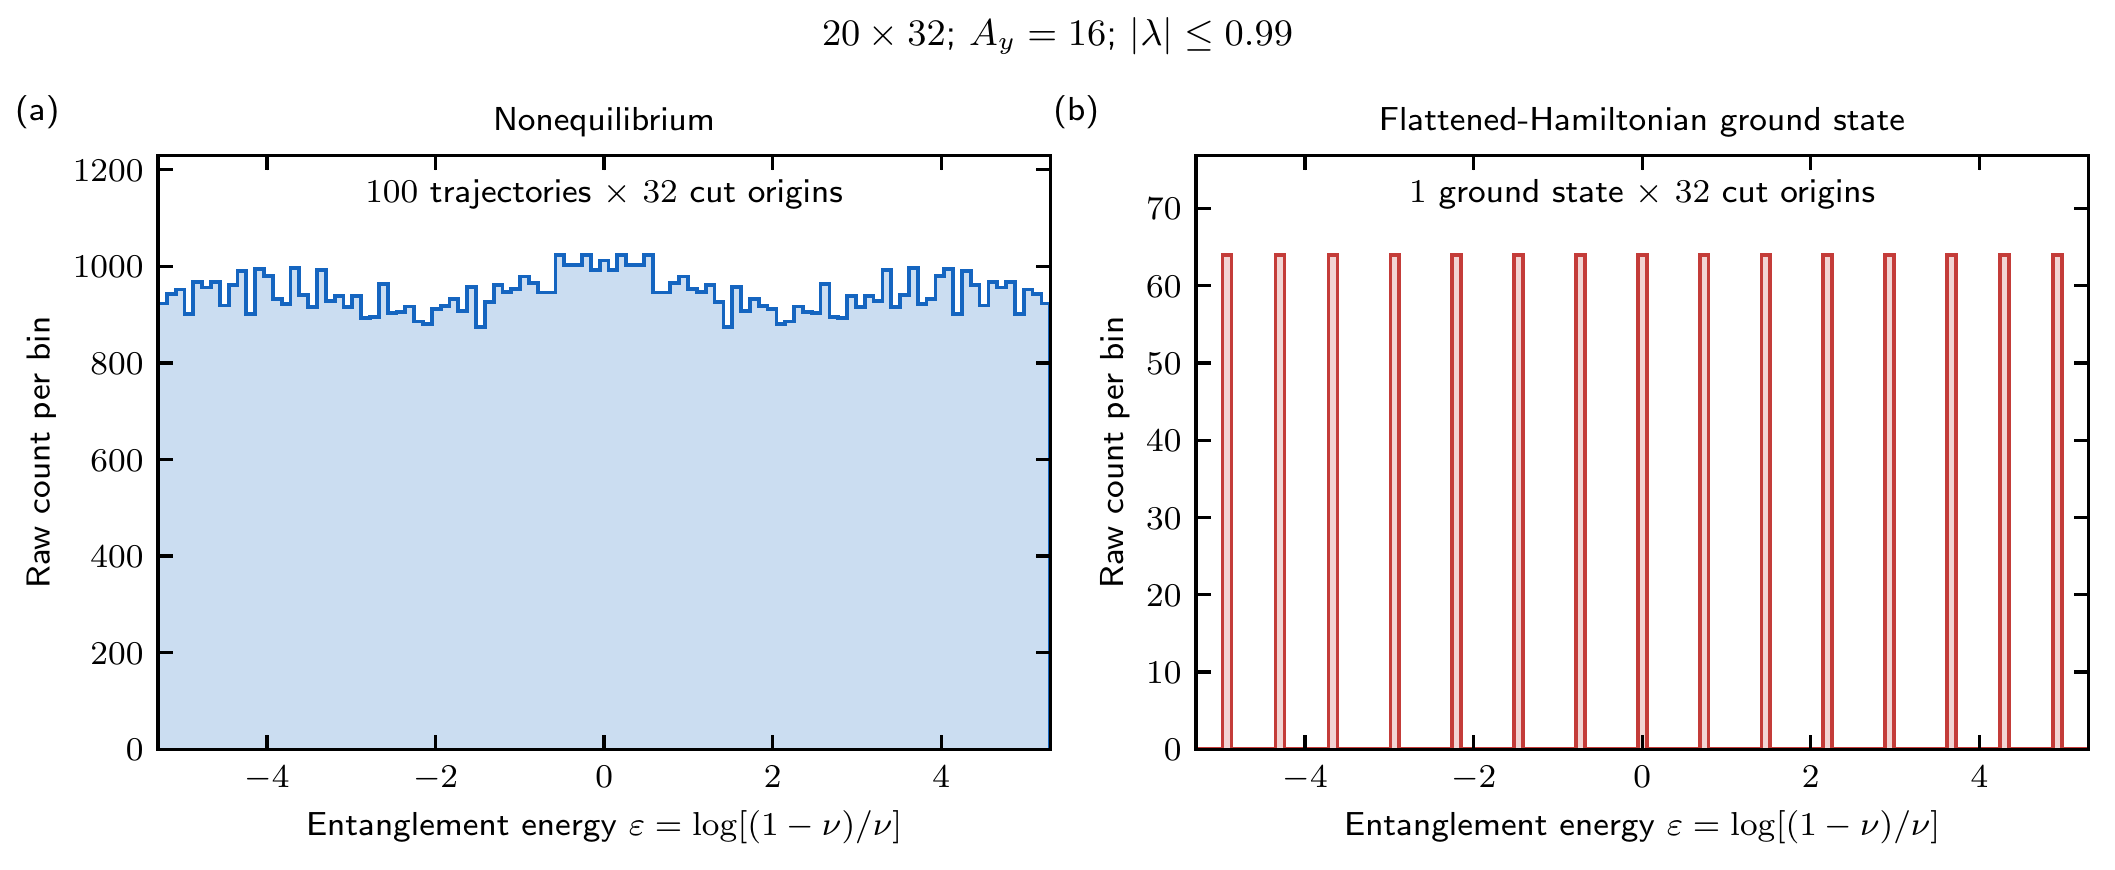

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
BINS=101
edges=np.linspace(-energy_limit,energy_limit,BINS+1)
st_counts,_=np.histogram(st_energy,edges)
eq_counts,_=np.histogram(eq_energy,edges)
assert st_counts.sum()==len(st_energy) and eq_counts.sum()==len(eq_energy)
previous=pd.read_csv(ST/'entanglement_energy_histogram.csv')
if BINS==len(previous):
    assert np.array_equal(st_counts,previous['count'])
pd.DataFrame({'energy_left':edges[:-1],'energy_right':edges[1:],
 'nonequilibrium_count':st_counts,'equilibrium_count':eq_counts}).to_csv(OUT/'histogram_counts.csv',index=False)
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],
 'font.size':8,'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,
 'text.usetex':True,'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in'})
fig,axes=plt.subplots(1,2,figsize=(7.05,2.9))
for ax,counts,color,title,note,letter in zip(axes,[st_counts,eq_counts],
 ['#1565c0','#c43c39'],['Nonequilibrium','Flattened-Hamiltonian ground state'],
 [r'$100$ trajectories $\times$ $32$ cut origins',r'$1$ ground state $\times$ $32$ cut origins'],['(a)','(b)']):
    ax.stairs(counts,edges,fill=True,color=color,alpha=.22)
    ax.stairs(counts,edges,color=color,linewidth=.9)
    ax.set(xlabel=r'Entanglement energy $\varepsilon=\log[(1-\nu)/\nu]$',
           ylabel='Raw count per bin',xlim=(-energy_limit,energy_limit),ylim=(0,counts.max()*1.2),title=title)
    ax.tick_params(top=True,right=True)
    ax.text(.5,.96,note,ha='center',va='top',transform=ax.transAxes,fontsize=8)
    ax.text(-.16,1.06,letter,transform=ax.transAxes,fontweight='bold')
fig.suptitle(r'$20\times32$; $A_y=16$; $|\lambda|\leq0.99$',fontsize=9)
fig.tight_layout(pad=.8)
fig.savefig(OUT/'entanglement_energy_comparison.pdf')
plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'entanglement_energy_comparison.pdf'),str(OUT/'entanglement_energy_comparison')],check=True)
display(Image(filename=str(OUT/'entanglement_energy_comparison.png'),width=1000))

## Diagnostics
Preserve exact counts, translation and spectral cross-checks, and energy conventions.

In [5]:
diagnostics={'L':L,'Ay':AY,'Nx':20,'Ny':32,'origins':32,'bins':BINS,'energy_limit':energy_limit,
 'nonequilibrium_raw_count':int(st_counts.sum()),'equilibrium_raw_count':int(eq_counts.sum()),
 'nonequilibrium_mean_retained_per_cut':float(st_counts_per_cut.mean()),
 'equilibrium_retained_per_cut':len(eq_single_energy),
 'equilibrium_hermiticity_error':hermiticity,'equilibrium_origin_matrix_max_error':max(origin_errors),
 'equilibrium_cached_spectrum_max_error':spectrum_error,'normalization':'none',
 'energy_convention':'epsilon=log[(1-nu)/nu]; |epsilon|=2 omega',
 'sampling':'100 nonequilibrium trajectories; 1 equilibrium ground state; 32 origins each'}
(OUT/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2)+'\n')
display(pd.Series(diagnostics))

L                                                                                     0.99
Ay                                                                                      16
Nx                                                                                      20
Ny                                                                                      32
origins                                                                                 32
bins                                                                                   101
energy_limit                                                                      5.293305
nonequilibrium_raw_count                                                             95398
equilibrium_raw_count                                                                  960
nonequilibrium_mean_retained_per_cut                                             29.811875
equilibrium_retained_per_cut                                                            30